In [16]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import emcee
import corner
import h5py
import numpy.ma as ma
from scipy.interpolate import interp1d
import pickle
import scipy.constants as const
from scipy import interpolate

In [2]:
import os
print(os.cpu_count())

32


## New RLC S11

In [3]:
RLC_S11_df = pd.read_csv('/home/saurabhs/Documents/gopi/Saras_New/Calibrated_ADHOC_S11_TEST4_SARAS4.csv')

RLC_S11 = list(RLC_S11_df.columns)
v=RLC_S11_df.iloc[0]
v=v*1e6
RLC_S11 = [float(i) for i in RLC_S11]
fit=np.polyfit(v,RLC_S11,6)
#print(fit)
p0,p1,p2,p3,p4,p5,p6=fit
model= np.polyval(fit,v)
res1=model-RLC_S11
#plt.plot(v,res1,'.')
#print(len(v))

## RLC Avg Data

In [4]:
avg = h5py.File('/home/saurabhs/Documents/amarnath/hdatasets/2025-04-13_053004.pyavg','r')

In [6]:
#Frequencies
avg['pyavg'].keys()
sfreq = avg.attrs['sfreq']
print(avg.attrs.keys())
freq=np.arange(0,8193,1)*sfreq*1e3
#print(freq)
ind_freq=np.logical_and((freq>=40),(freq<=110))
#print(freq[ind_freq])
req_freq=freq[ind_freq]*1e6
len_freq=len(req_freq)


<KeysViewHDF5 ['sfreq']>


### Interpolating the RLC for the required frequencies

In [8]:
#Interpolating the RLC for the required frequencies
interpolator = interp1d(v, RLC_S11, kind='linear')
freq_new = np.linspace(v.min(), v.max(), len_freq)
#print(len(freq_new))
RLC_new=interpolator(freq_new) ##Interpolated RLC

#plt.plot(req_freq,RLC_new)
#plt.show()

In [10]:
#New Fit
fit=np.polyfit(req_freq,RLC_new,6)
#print(fit)
p0,p1,p2,p3,p4,p5,p6=fit
model= np.polyval(fit,req_freq)
res=model-RLC_new
#plt.plot(req_freq,res,'.')
#plt.plot(v,res1)

### Reading the avg data

In [11]:
SPCD_avg=avg['SPCD'][0, ind_freq].real
SPCF_avg=avg['SPCF'][0, ind_freq].real
mask_avg=avg['mask'][0, ind_freq].real
#print(len(mask_avg))

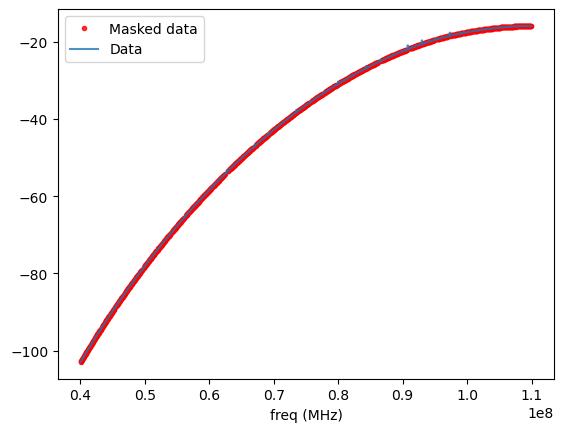

In [12]:
#Masking the unwanted frequencies
TMeas_exp_avg=ma.masked_array(SPCD_avg,np.logical_not(mask_avg))  ##Masking
plt.plot(req_freq,TMeas_exp_avg,'r.', label='Masked data', alpha=0.8)
plt.plot(req_freq,SPCD_avg, alpha=0.8, label='Data')
plt.xlabel('freq (MHz)')
plt.legend()
plt.show()

In [15]:
##Masking Uncertainities
uncert=ma.masked_array(SPCF_avg,np.logical_not(mask_avg))
"""
plt.plot(req_freq,uncert,'r.', label='Masked data', alpha=0.8)
#plt.plot(req_freq,SPCF_avg, alpha=0.8, label='Data')
plt.xlabel('freq (MHz)')
plt.legend()
plt.show()
print(uncert.shape)
"""

"\nplt.plot(req_freq,uncert,'r.', label='Masked data', alpha=0.8)\n#plt.plot(req_freq,SPCF_avg, alpha=0.8, label='Data')\nplt.xlabel('freq (MHz)')\nplt.legend()\nplt.show()\nprint(uncert.shape)\n"

### Model

In [18]:
def Compute_Tmeas_RLC(PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=Pref
    c=const.c
    l=l
    N=7
    global req_freq #[d[i][0] for i in range(len(d))]
    for i in range(len(req_freq)):
        gamma_A=p0*1e-48*req_freq[i]**(N - 1) + p1*1e-40*req_freq[i]**(N - 2) + p2*1e-31*req_freq[i]**(N - 3) + p3*1e-23*req_freq[i]**(N - 4) + p4*1e-16*req_freq[i]**(N - 5) + p5*1e-08*req_freq[i]**(N - 6) + p6*1e-01
        
        phi= (4*math.pi*(req_freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A)**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A)**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA*(1-(gamma_A**2))*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A)**2)*C))
    return Tmeas

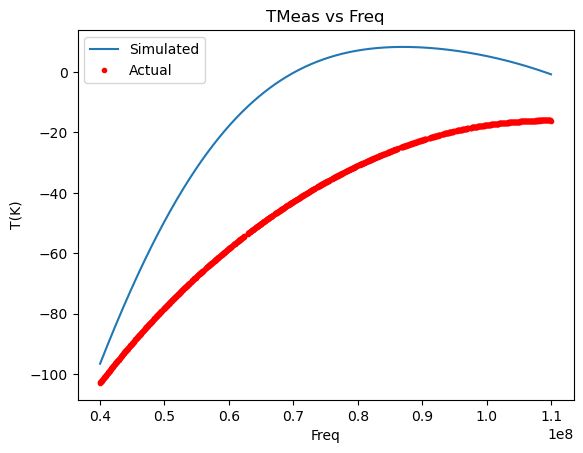

In [20]:
#Simulated signal vs Actual averaged signal
T=Compute_Tmeas_RLC(300,300, -2.52316013,  9.27244989, -1.40037092,  1.25994681, -7.15007581,  1.24280736,  8.85664268, 70, 0.3, 0.1, 0.15)

plt.plot(req_freq,T, label="Simulated")
plt.plot(req_freq,TMeas_exp_avg,'r.',label="Actual")
plt.legend()
plt.xlabel("Freq")
plt.ylabel("T(K)")
plt.title("TMeas vs Freq")
plt.show()

## 21cm signal

In [21]:
path_to_file = '/home/saurabhs/Documents/gopi/Saras_New/Data_18March_wMFP.mat'
path_to_freq = '/home/saurabhs/Documents/gopi/Saras_New/freq_saras.txt'

data     = scipy.io.loadmat(path_to_file)
data     = data['Data2']/1e3  # Kelvin units

fr       = np.loadtxt(path_to_freq) #Frequency in MHz
signal_function   = interpolate.interp1d(fr, data, fill_value="extrapolate")

In [22]:
F_MIN = 40 # define your own

F_MAX = 110 # define your own

NO_OF_CHANNELS = len_freq # define your own

freq_array = np.linspace(F_MIN, F_MAX, NO_OF_CHANNELS) 

signals = signal_function(freq_array)

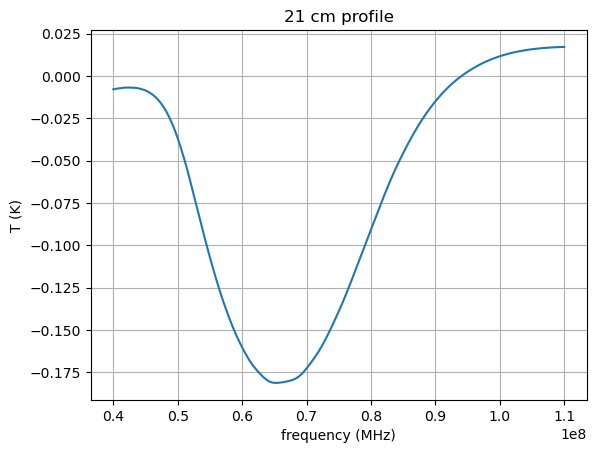

In [23]:
sig_idx = 63
sig21cm=signals[sig_idx]
plt.plot(req_freq, sig21cm)

plt.title('21 cm profile')
plt.xlabel('frequency (MHz)')
plt.ylabel('T (K)')
plt.grid(True)
plt.show()

### Adding the 21cm signal (Avg signal + 21cm signal)

In [24]:
a=1
T21=a*sig21cm+TMeas_exp_avg

#plt.plot(req_freq,T21, 'k', zorder=1)
#plt.plot(req_freq,TMeas_exp_avg, '.r', zorder=2)


## Open

In [25]:
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/home/saurabhs/Documents/gopi/Saras_New/saras3_S11_200mm_above_water.s1p", skiprows=5))

d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
c=const.c  # speed of light (m/s)
freq=[d[i][0] for i in range(len(d)-1)] #frequency
#df=pd.read_csv('/home/saurabhs/Documents/gopi/Saras_New/S11_for_freq.csv')
#rlc = df[df.columns[1]].values.tolist()
"""
RLC_S11_df = pd.read_csv('/home/saurabhs/Documents/gopi/Saras_New/Calibrated_ADHOC_S11_TEST4_SARAS4.csv')

RLC_S11 = list(RLC_S11_df.columns)
v=RLC_S11_df.iloc[0]
RLC_S11 = [float(i) for i in RLC_S11]
rlc= RLC_S11[::-1]
print(v[0],RLC_S11[0])
plt.plot(v, RLC_S11)
"""

"\nRLC_S11_df = pd.read_csv('/home/saurabhs/Documents/gopi/Saras_New/Calibrated_ADHOC_S11_TEST4_SARAS4.csv')\n\nRLC_S11 = list(RLC_S11_df.columns)\nv=RLC_S11_df.iloc[0]\nRLC_S11 = [float(i) for i in RLC_S11]\nrlc= RLC_S11[::-1]\nprint(v[0],RLC_S11[0])\nplt.plot(v, RLC_S11)\n"

In [26]:
def Compute_Tmeas_(PA, gamma_A, PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=300
    l=l
    freq= [d[i][0] for i in range(len(d)-1)]
    for i in range(len(freq)):
        
        phi= (4*math.pi*(freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A)**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A)**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A)**2)*C))
    return(Tmeas)

## MCMC for Open

In [20]:
########## Define the log-likelihood function
def log_likelihood_o(params,**kwargs):
    ip_params=kwargs["ip_params"]
    seed=kwargs["seed"]
    s = kwargs["s"]  # Uncertainty
    
    PA, gamma_A, PN, gamma_N, f, l = params
    
    # Define the Expected TA values
    
    np.random.seed(seed)
    TA_exp = Compute_Tmeas_(*ip_params) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp=np.array(TA_exp)
    
    # Compute model TA
    TA_model = Compute_Tmeas_(PA, gamma_A, PN, gamma_N, f,  l)
    TA_model=np.array(TA_model)

    # Compute chi-squared with weights
    
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 #- np.log(math.sqrt(2*np.pi)*s)  # Likelihood function

########## Define the log-prior function
def log_prior_o(params):
    
    PA, gamma_A, PN, gamma_N, f, l = params

    if ((0 <= gamma_A <= 1) and (0 <= gamma_N <= 1) and (0<=PA<=3) and (50<=PN<=150) and (0.05<=f<=0.5) and (0.05<l<2)) : 
            return 0.0  # Reject sample
    return -np.inf # Uniform prior

######### Define the full log-probability function

def log_probability_o(params,**kwargs):
    lp = log_prior_o(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_o(params,**kwargs)

########### MCMC

def evolve_MCMC_o(**kwargs):# Define parameter names
    parameter_names = ["PA", "gamma_A", "PN", "gamma_N", "f","l"]

    # Number of walkers and steps
    ndim = 6  # Number of parameters
    nwalkers = 200  # Number of MCMC walkers
    nsteps = kwargs["nsteps"]  # Number of MCMC steps per walker
    
    # Initialize walkers around a random point in parameter space
    initial_value= np.array(kwargs["initial_value"])
    
    ## Starting positions for the walkers
    seed=kwargs["seed"]
    np.random.seed(seed+1)
    
    pos= initial_value[None,:] + initial_value*1e-2*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*

    #Make sure all the positions are positive
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    
    #pos= initial_exact+ 1e-1*np.array([[np.random.uniform(min_v, max_v) for min_v, max_v in zip(min_values, max_values)] for _ in range(nwalkers)]) 

    def wrap_log_probability_o(params):
        return log_probability_o(params,**kwargs)
        
    ############ Set up the MCMC sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, wrap_log_probability_o, threads=10)
    print(sampler.acceptance_fraction) #Mean Acceptance Ration
    ############ Run MCMC
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ############ Extract the samples
    #samples = sampler.flatchain
    full_samples_o=sampler.get_chain()

    samples_o = sampler.get_chain(discard=500, flat=True)

    ######### Compute log-likelihoods for all samples
    log_likes_o = np.array([log_likelihood_o(p, **kwargs) for p in samples_o])
    
    ######### Find the index of the maximum likelihood
    max_likelihood_index = np.argmax(log_likes_o)
    
    ########## Get the best-fit parameters
    best_fit_params_o = samples_o[max_likelihood_index].tolist()

    return full_samples_o,samples_o,best_fit_params_o

In [20]:
#evolve MCMC
ip_params=[0,1,70,0.3,0.1,0.15] #input parameters
nsteps=3000
initials=[0.007,0.97,70.7,0.29,0.1,0.13]
s=0.01
seed=6
kwargs={"s":s,"seed":seed, "nsteps":nsteps, "ip_params":ip_params, "initial_value":initials}
full_samples_o, samples_o, best_fit_params_o= evolve_MCMC_o(**kwargs)

/home/saurabhs/anaconda3/envs/saras/lib/python3.11/site-packages/emcee/ensemble.py:542: RuntimeWarning: invalid value encountered in divide
  return self.backend.accepted / float(self.backend.iteration)


[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
Running MCMC...


  0%|▏                                        | 11/3000 [00:03<13:47,  3.61it/s]Traceback (most recent call last):
  File "/home/saurabhs/anaconda3/envs/saras/lib/python3.11/site-packages/emcee/ensemble.py", line 624, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_776169/1547612243.py", line 69, in wrap_log_probability_o
    return log_probability_o(params,**kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_776169/1547612243.py", line 40, in log_probability_o
    return lp + log_likelihood_o(params,**kwargs)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_776169/1547612243.py", line 16, in log_likelihood_o
    TA_model = Compute_Tmeas_(PA, gamma_A, PN, gamma_N, f,  l)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_776169/1037848549.py", line 19, in Compute_Tmeas_
    B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma

emcee: Exception while calling your likelihood function:
  params: [6.85038718e-03 9.09438943e-01 7.30461133e+01 3.04060682e-01
 9.84347045e-02 1.32368669e-01]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

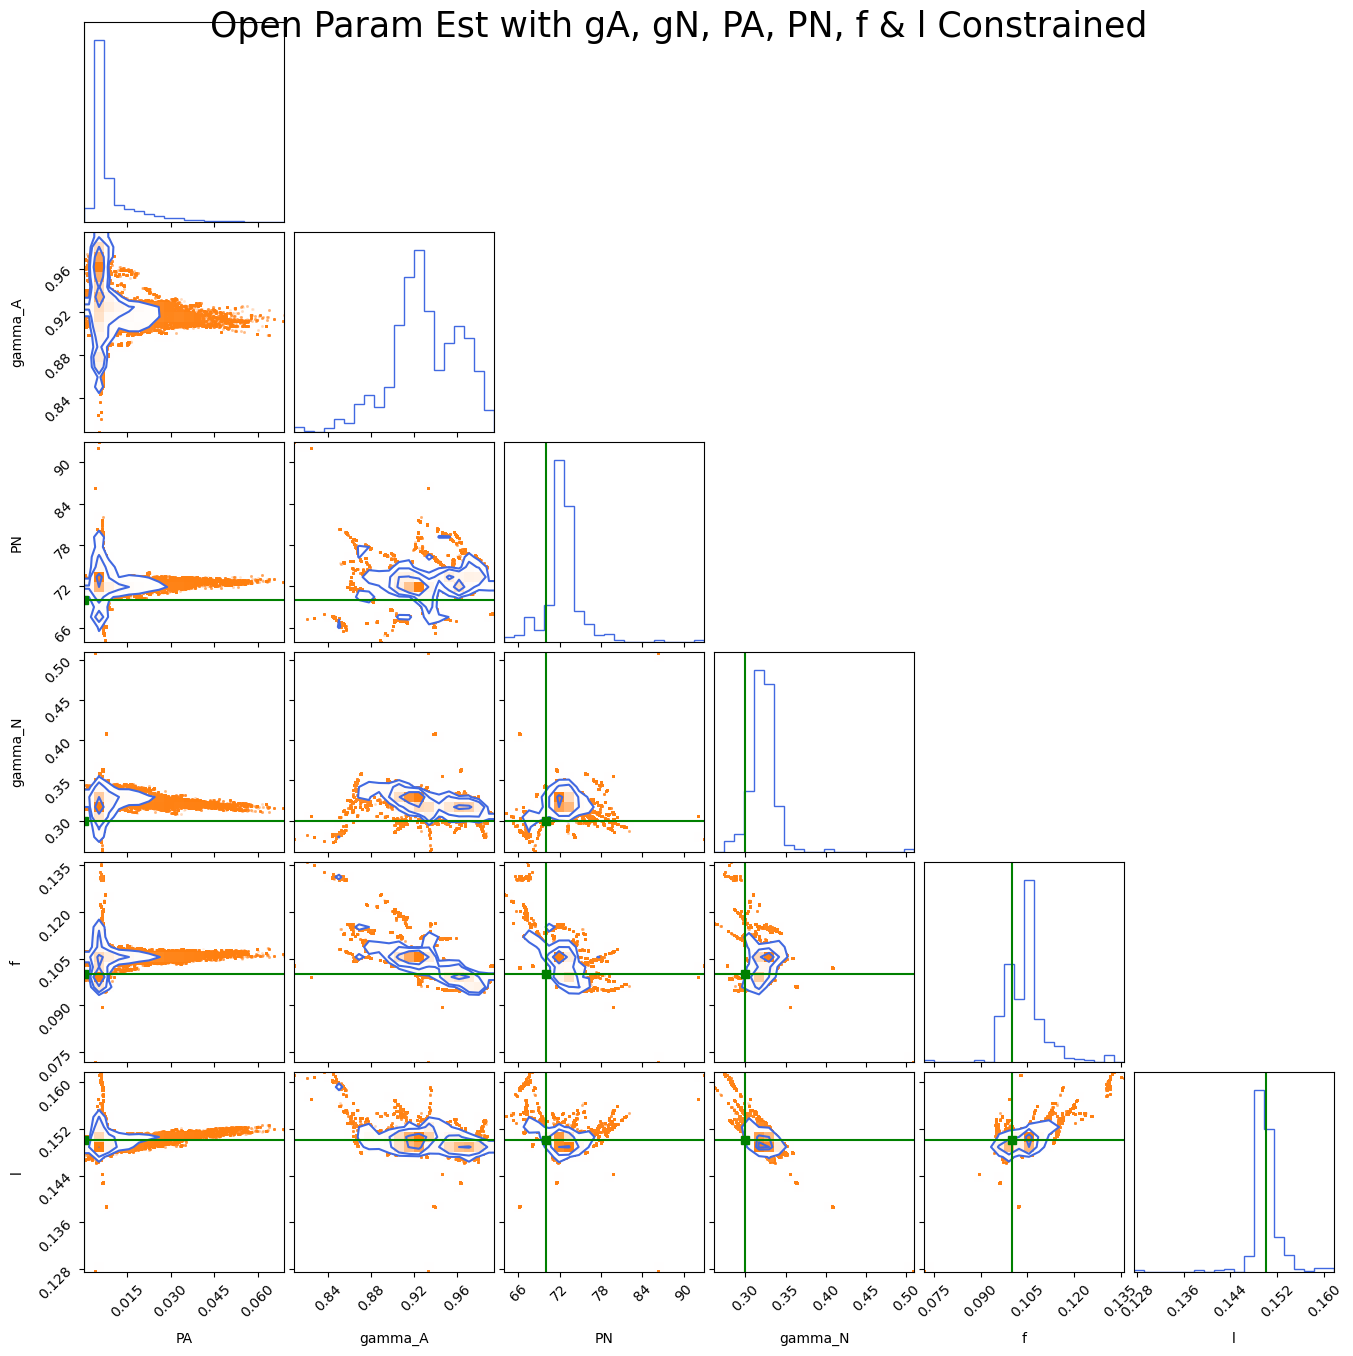

Best-fit parameters (Maximum Likelihood Estimate): [0.02067051374784898, 0.9287089069170731, 71.43706303809641, 0.3185361042112389, 0.10595717787819937, 0.15067380390226337]


In [82]:
parameter_names = ["PA", "gamma_A", "PN", "gamma_N", "f","l"]
#corner plot 
fig = corner.corner(samples_o, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
plt.suptitle("Open Param Est with gA, gN, PA, PN, f & l Constrained", fontsize=25)
#plt.savefig('/home/saurabhs/Documents/gopi/Saras_Model/Untitled Folder/Open_All_15cm_1.png', dpi=300)
plt.show()

#print("Expected Paramerters:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params_o)

## MCMC for RLC real data with S11 fixed

In [27]:
########## Define the log-likelihood function
def log_likelihood_full(params,**kwargs):

    # Compute TA expected
    seed=kwargs["seed"]
    #ip_params=kwargs["ip_params"]
    v=kwargs["v"]
    s=kwargs["s"]
    TA_exp=kwargs["TMeas_exp"]
    p0, p1, p2, p3, p4, p5, p6 = kwargs["S11_params"]
    signal=kwargs["signal"]
    
    np.random.seed(seed)
    
    # Compute model TA

    a, PA, Pref, PN, gamma_N, f, l = params
    TA_model = Compute_Tmeas_RLC(PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l) 
    TA_model=np.array(TA_model)+a*signal

    # Compute chi-squared
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 #- np.log(math.sqrt(2*np.pi)*s)

########## Define the log-prior function
def log_prior_full(params, **kwargs):

    a, PA, Pref, PN, gamma_N, f, l = params
    #v=kwargs["v"]
    #PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l = params
    #gamma_A=np.polyval([p0*1e-48, p1*1e-39, p2*1e-31, p3*1e-23, p4*1e-15, p5*1e-08, p6*1e-01],v)
    
    if (a>0 and 0<=gamma_N<=1 and PA>0 and Pref>0 and PN>0 and f>0 and l>0): #np.amin(gamma_A)>=0 and np.amax(gamma_A)<=1 and ):
        return 0.0  # Accept sample
    
    return -np.inf # Reject prior
        
    
######### Define the full log-probability function
    
def log_probability_full(params, **kwargs):
    lp = log_prior_full(params,**kwargs)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_full(params,**kwargs)


########## MCMC for RLC Coeffs.
def evolve_MCMC_Full(**kwargs):
    
    # Define parameter names
    #parameter_names = ["PA", "p0", "p1", "p2", "p3", "p4", "p5", "p6", "PN", "gamma_N", "f", "l"]

    #args=args
    
    ## Number of walkers and steps
    
    ndim = 7  # Number of parameters
    nwalkers = 150  # Number of MCMC walkers
    nsteps = kwargs["nsteps"]  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    
    initial_value=kwargs["initial_value"]

    ## Starting positions for the walkers (making sure that the initial positions satisfy the priors)
    
    pos_valid = []
    while len(pos_valid) < nwalkers:
        trial = initial_value + 1e-1 * np.random.randn(ndim)
        if np.isfinite(log_prior_full(trial, **kwargs)):
            pos_valid.append(trial)
    pos = np.array(pos_valid)
    #pos= initial_value + 1e-1*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*
    
    
    ## for making sure only positive positional values
    """
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 
    
    def wrapped_log_prob_full(params):
        return log_probability_full(params, **kwargs)
    
    ## Set up the MCMC sampler
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, wrapped_log_prob_full, threads=15)
    
    ## Run MCMC
    
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=500, flat=True)

    ## Compute log-likelihoods for all samples
    
    log_likes = np.array([log_likelihood_full(p, **kwargs) for p in samples])
    
    ## Find the index of the maximum likelihood
    
    max_likelihood_index = np.argmax(log_likes)
    
    ## Get the best-fit parameters
    
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples,samples,best_fit_params, pos

In [ ]:
#evolve MCMC full with initials for system parameters from Open
S11_params=[-1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821]
seed=61
a=0 ## multiplication factor for the signal
PA, Pref, PN, gN, f, l=[300, 300, 70, 0.2, 0.1, 0.15]#best_fit_params_o
initials=[a, PA, Pref, PN, gN, f, l]
nsteps=3000
TMeas_=Compute_Tmeas_RLC(313.44495298597064, 307.2088350626911,p0, p1, p2, p3, p4, p5, p6, 74.23509620659401, 0.19840997630322196, 0.4260990319365141, 0.21653155250707493)#T21
TMeas_exp=np.array(TMeas_)#+sig21cm
v=req_freq
signal= sig21cm
s=0.01 ## uncertainity
kwargs = {"s":s, "v":v, "seed":seed, "nsteps":nsteps, "initial_value":initials, "TMeas_exp":TMeas_exp, "S11_params":S11_params, "signal":signal} #"ip_params":ip_params}

full_samples_full, samples_full, best_fit_params_full, initial_pos= evolve_MCMC_Full(**kwargs)

Running MCMC...


 31%|██████████████████████████                                                         | 942/3000 [55:55<1:56:28,  3.40s/it]

In [37]:
#Saving in a pickel file
# Ask user for confirmation
parameter_names = ["a","PA", "Pref", "PN", "gamma_N", "f", "l"]
ip_params=[1,313.44495298597064, 307.2088350626911, 74.23509620659401, 0.19840997630322196, 0.4260990319365141, 0.21653155250707493]
confirm = input("Do you want to save the pickle file? (y/n): ").strip().lower()
if confirm == "y":
    result={"seed":seed, "samples":samples_full, "best_fit":best_fit_params_full, "param_names":parameter_names, "ip_params":ip_params}

    with open(f"results_{seed}.pkl", 'wb') as f:  # open a text file
        pickle.dump(result, f) # serialize the list

    f.close()
else:
     print("Save cancelled.")

Do you want to save the pickle file? (y/n): y


Text(0.5, 1.0, 'Nothing to see here')

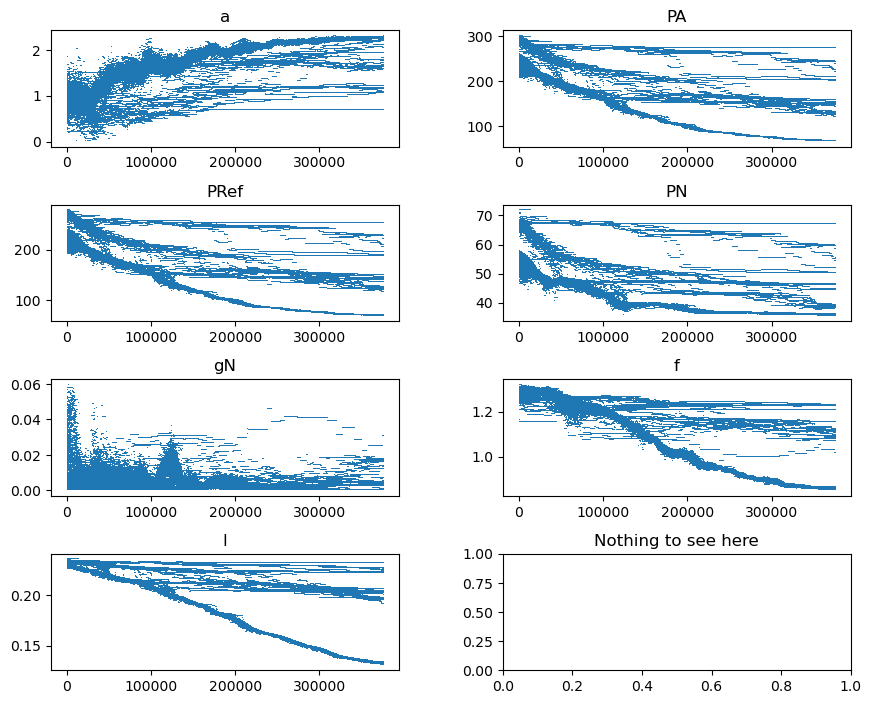

In [38]:
fig, axes = plt.subplots(4, 2, figsize=(10, 8))

plt.subplots_adjust(
    left=0.1,    # Left margin
    right=0.9,   # Right margin
    bottom=0.1,  # Bottom margin
    top=0.9,     # Top margin
    wspace=0.3,  # Width space between columns (fraction of average axis width)
    hspace=0.5   # Height space between rows (fraction of average axis height)
)


axes[0,0].plot(samples_full[:,0],',')
axes[0,0].set_title('a')

axes[0,1].plot(samples_full[:,1],',')
axes[0,1].set_title('PA')

axes[1,0].plot(samples_full[:,2],',')
axes[1,0].set_title('PRef')

axes[1,1].plot(samples_full[:,3],',')
axes[1,1].set_title('PN')

axes[2,0].plot(samples_full[:,4],',')
axes[2,0].set_title('gN')

axes[2,1].plot(samples_full[:,5],',')
axes[2,1].set_title('f')

axes[3,0].plot(samples_full[:,6],',')
axes[3,0].set_title('l')

axes[3,1].set_title('Nothing to see here')

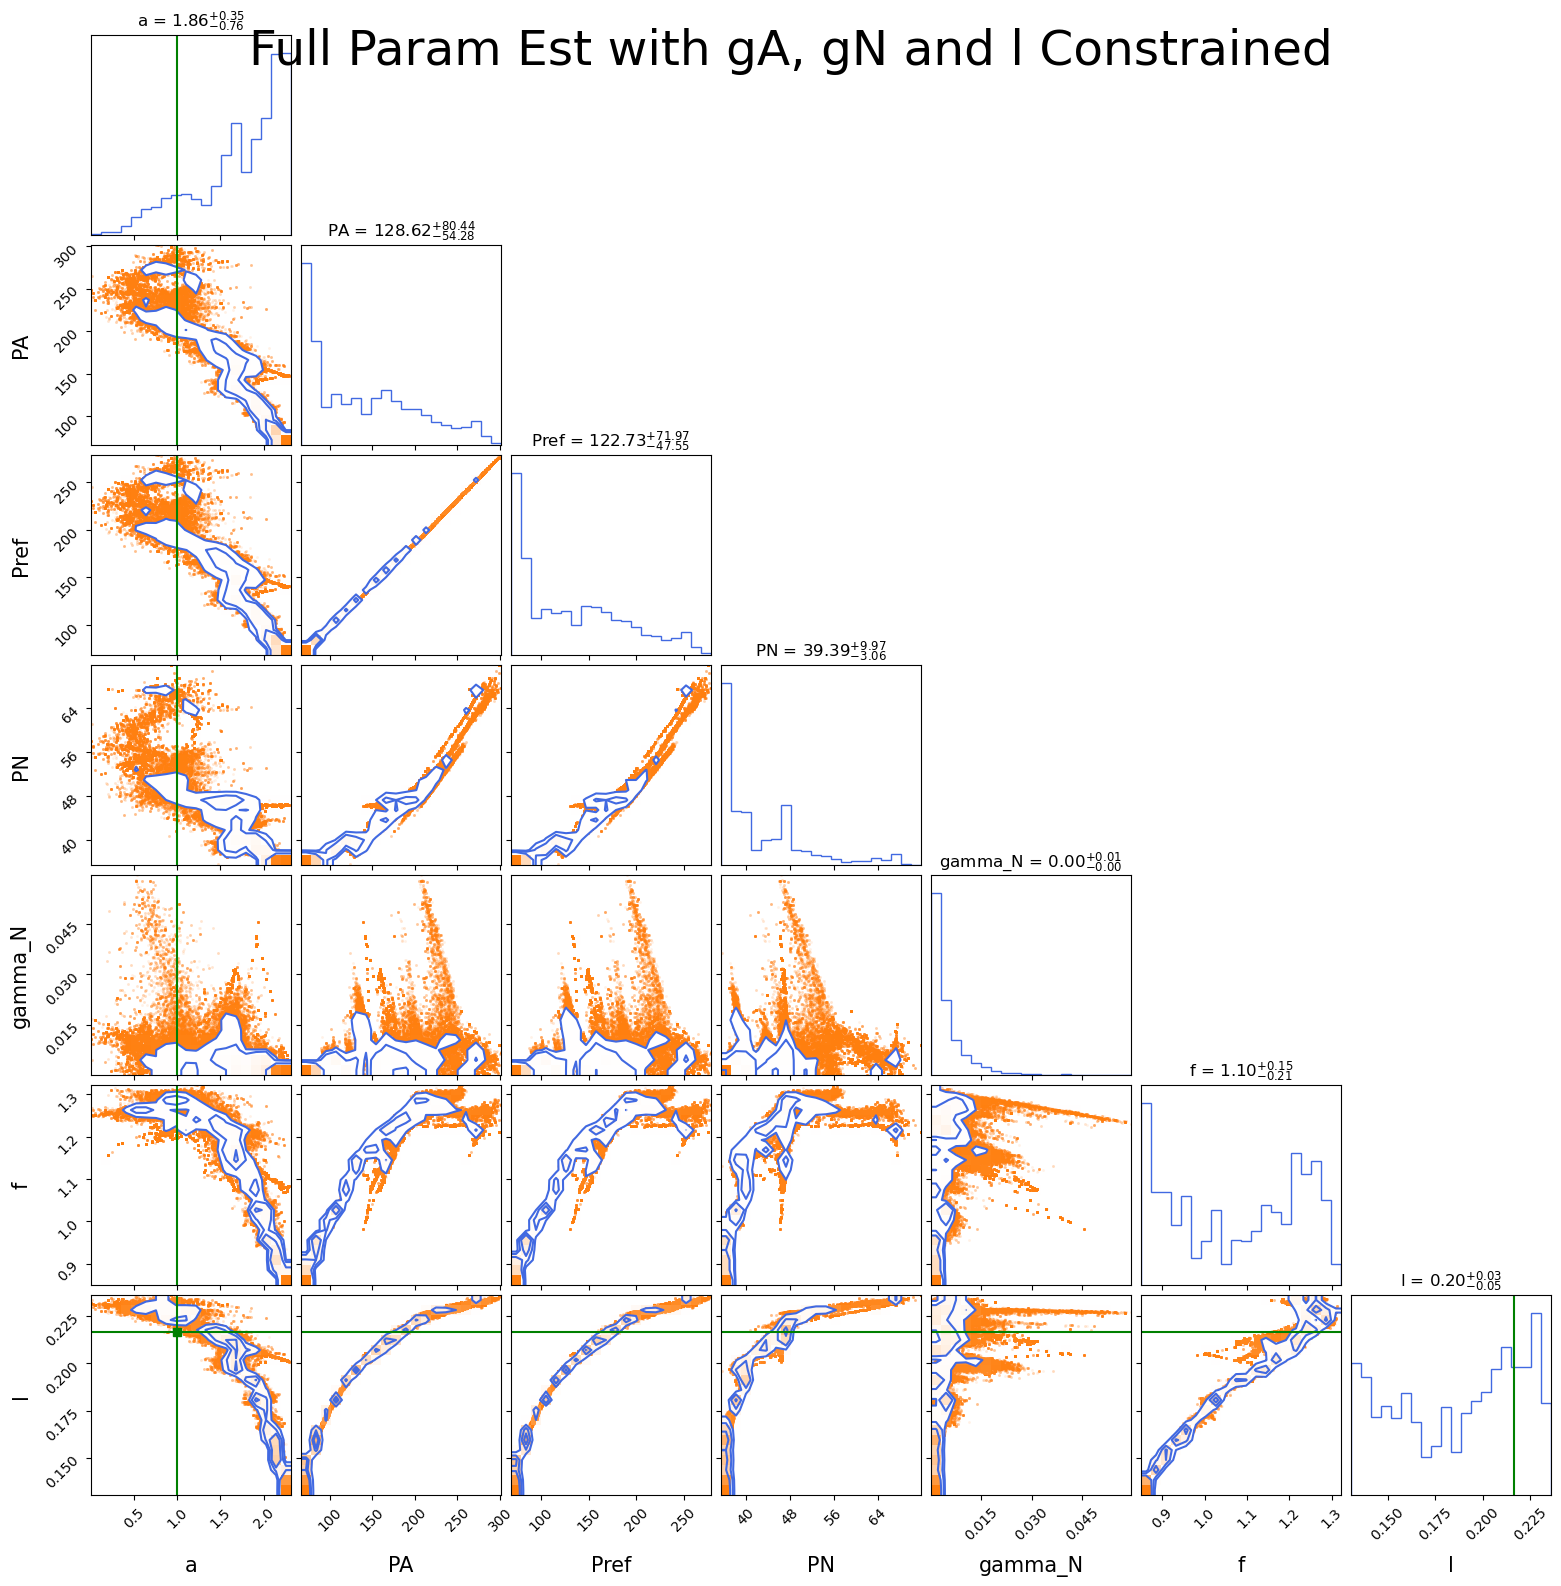

Best-fit parameters (Maximum Likelihood Estimate): [2.2715632606853746, 66.94875363971995, 68.99154746688885, 35.97042321280862, 8.885903274752308e-06, 0.8513239330806317, 0.13182338431070736]


In [39]:

#corner plot 
fig = corner.corner(samples_full, labels=parameter_names, show_titles=True, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
label_kwargs={"fontsize":15}, #set label size
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
plt.suptitle("Full Param Est with gA, gN and l Constrained", fontsize=35)
#plt.savefig('/home/saurabhs/Documents/gopi/Saras_Model/RLC_Full_gA_1m_.png', dpi=300)
#plt.savefig('Art.png')

plt.show()

#print("Expected Paramerters:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params_full)

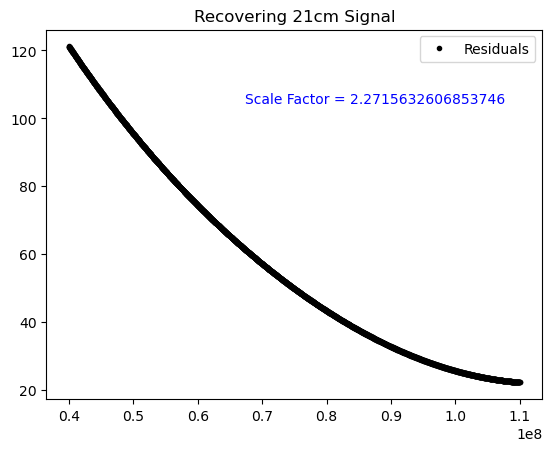

In [40]:
#Recovering 21cm Signal
a, PA, Pref, PN, gN, f, l = best_fit_params_full
p0, p1, p2, p3, p4, p5, p6 = [-1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821]
Tbest=Compute_Tmeas_RLC(PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gN, f, l)+(a*sig21cm)

TMeas_=Compute_Tmeas_RLC(313.44495298597064, 307.2088350626911,p0, p1, p2, p3, p4, p5, p6, 74.23509620659401, 0.19840997630322196, 0.4260990319365141, 0.21653155250707493)#T21
TMeas_exp=np.array(TMeas_)+sig21cm
recovery=(Tbest-TMeas_exp)
#plt.plot(req_freq,recovery,'.k')
#plt.plot(req_freq, sig21cm,'r')
plt.plot(req_freq, recovery,'.k',label="Residuals" )
#plt.plot(req_freq,sig21cm,'.r', label="21cm Signal")

plt.text(0.4, 0.8, f"Scale Factor = {a}", transform=plt.gca().transAxes,
         fontsize=10, color='blue')
plt.title("Recovering 21cm Signal")
plt.legend()
plt.show()

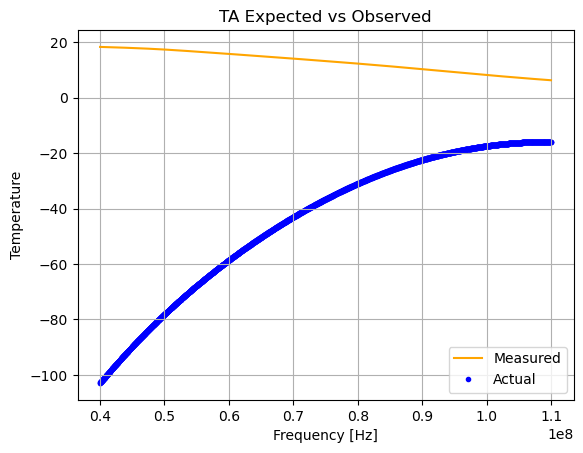

In [41]:
#Expected vs Observed TMeas signal

plt.plot(req_freq, Tbest, label='Measured', color='orange')
plt.plot(req_freq, TMeas_exp, '.', label='Actual', color='blue',zorder=-1)
plt.title("TA Expected vs Observed")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()


Text(0, 0.5, 'S11')

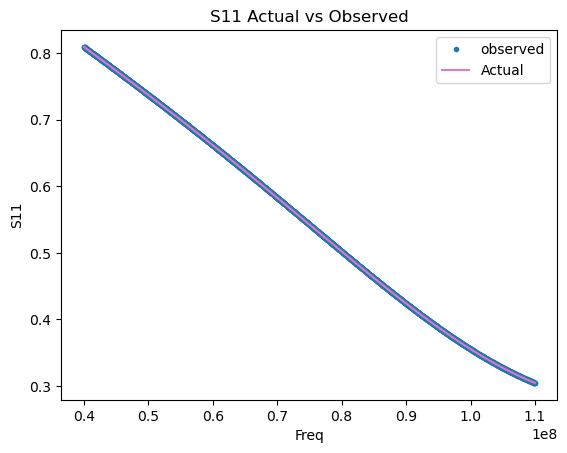

In [30]:
#Reconstructed S11 wrt best fit
v=req_freq
p0, p1, p2, p3, p4, p5, p6= [-1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821]
a, PA, Pref, PN, gamma_N, f, l =best_fit_params_full
gamma_A=np.polyval([p0*1e-48, p1*1e-40, p2*1e-31, p3*1e-23, p4*1e-16, p5*1e-8, p6*1e-1],req_freq)

p0, p1, p2, p3, p4, p5, p6=[-1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821]
gA_True=np.polyval([p0*1e-48, p1*1e-40, p2*1e-31, p3*1e-23, p4*1e-16, p5*1e-8, p6*1e-1],req_freq)

yerr=abs(gA_True-gamma_A)
#plt.errorbar(v, gamma_A, yerr, fmt=".C9", capsize=0, label="Error")
plt.plot(v,gamma_A,'.', label='observed')
plt.plot(v,gA_True,'tab:pink', label='Actual')
plt.title("S11 Actual vs Observed")
plt.legend()
plt.xlabel('Freq')
plt.ylabel('S11')

In [90]:
#computing S11 corresponding to all samples
reduced_samples_rlc = samples_full
S11_models_rlc = np.zeros((len(reduced_samples_rlc), len(req_freq)))

for ii in range(len(reduced_samples_rlc)):
    a, PA, Pref, PN, gamma_N, f, l= reduced_samples_rlc[ii]
    S11_models_rlc[ii]=np.polyval([p0*1e-48, p1*1e-40, p2*1e-31, p3*1e-23, p4*1e-16, p5*1e-8, p6*1e-1],req_freq)

Text(0.5, 1.0, 'Residuals for all samples')

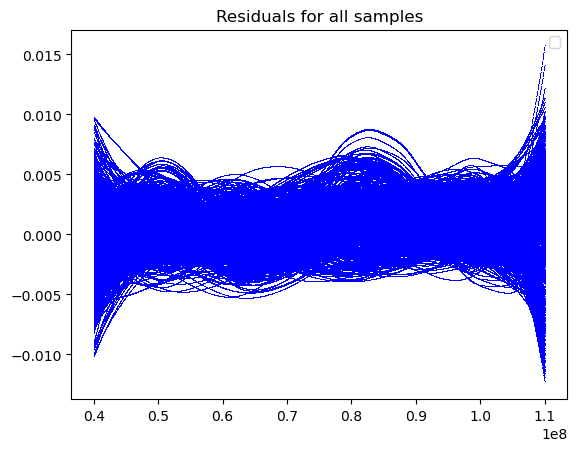

In [91]:
#Residuals for all samples
sample_indices = np.arange(0, len(reduced_samples_rlc),100)
TA= np.zeros((len(sample_indices), len(req_freq)))
res= np.zeros((len(sample_indices), len(req_freq)))
for jj, ii in enumerate(sample_indices):
    a, PA, Pref, PN, gamma_N, f, l= reduced_samples_rlc[ii]
    TA_obs=Compute_Tmeas_RLC(PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l)+(a*sig21cm)
    TA_obs=np.array(TA_obs)
    TA[jj] = TA_obs
    res[jj]= (TA_obs-TMeas_exp)
    #plt.plot(req_freq_valid, TA[ii],color='C1', marker="|", alpha=0.1, lw=1)
    plt.plot(req_freq,res[jj].T,',b')
    
#plt.legend()
plt.title("Residuals for all samples")

In [93]:
TA_mean=np.mean(TA, axis=0)
residuals_mean=TA_mean-TMeas_exp

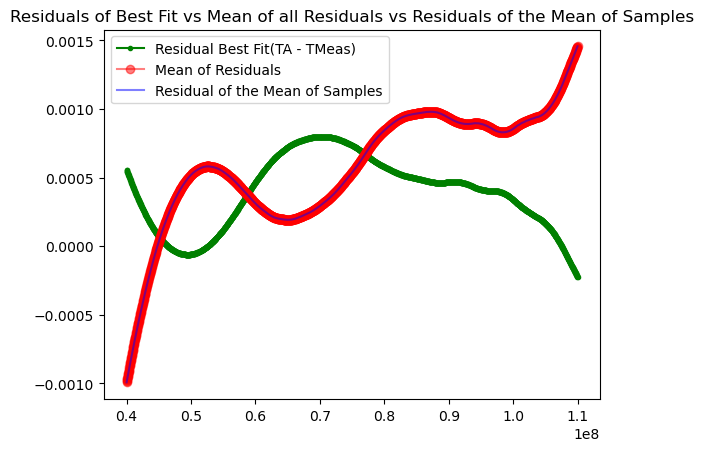

In [96]:
#Residuals of Best Fit vs Mean of all Residuals vs Residuals of the Mean of Samples
plt.plot(req_freq, recovery, label='Residual Best Fit(TA - TMeas)', color='green', marker='.')
plt.plot(req_freq,np.mean(res, axis=0), alpha=0.5, label='Mean of Residuals', color='red',marker='o')
plt.plot(req_freq,residuals_mean, alpha=0.5, label='Residual of the Mean of Samples', color='blue')
plt.legend()
plt.title('Residuals of Best Fit vs Mean of all Residuals vs Residuals of the Mean of Samples')
plt.show()

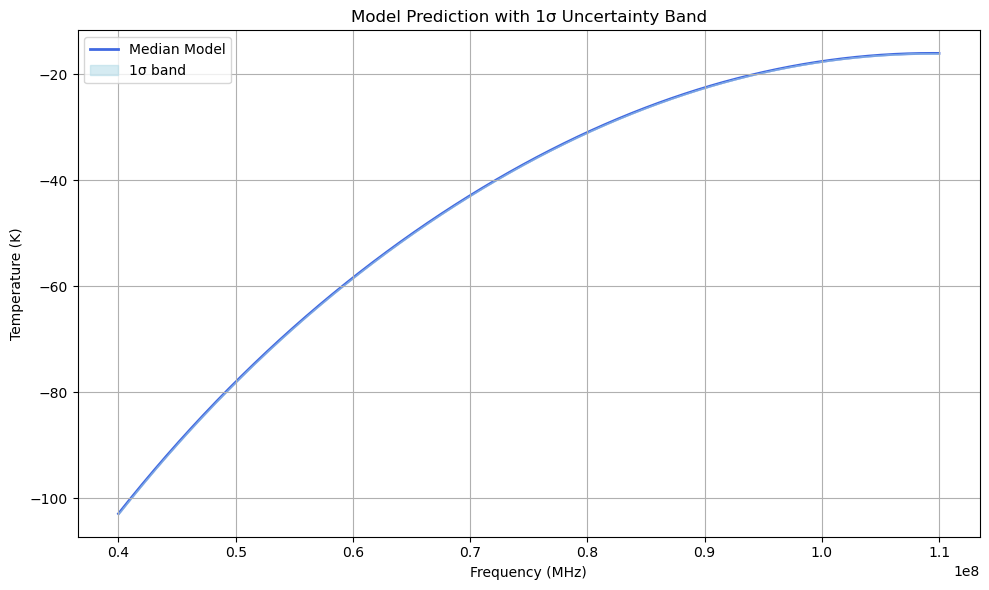

In [98]:
# Compute percentiles for 1-sigma band
TA_lower = np.percentile(TA, 16, axis=0)
TA_upper = np.percentile(TA, 84, axis=0)
TA_median = np.percentile(TA, 50, axis=0)

# Plot
plt.figure(figsize=(10, 6))
#plt.plot(req_freq, TA_true, label='Measured (TMeas)', color='black', marker='.', linewidth=1, zorder=1)
plt.plot(req_freq, TA_median, label='Median Model', color='royalblue', linewidth=2, zorder=0)
plt.fill_between(req_freq, TA_lower, TA_upper, color='lightblue', alpha=0.5, label='1σ band')

plt.xlabel("Frequency (MHz)")
plt.ylabel("Temperature (K)")
plt.title("Model Prediction with 1σ Uncertainty Band")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
#Recovering Uncertainities in Tmeas
TMeas=T21
TMeas_clean = np.ma.filled(TMeas, fill_value=np.NAN)

sample_indices = np.arange(0, len(reduced_samples_rlc),100)
TA= np.zeros((len(sample_indices), len(req_freq)))
res= np.zeros((len(sample_indices), len(req_freq_valid)))
for jj, ii in enumerate(sample_indices):
    a, PA, Pref, PN, gamma_N, f, l= reduced_samples_rlc[ii]
    p0, p1, p2, p3, p4, p5, p6=[-1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821]
    TA_obs=Compute_Tmeas_RLC(PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l)
    TA_obs=np.array(TA_obs)
    TA[jj] = TA_obs[valid_mask]
    res[jj]= (TA_obs[valid_mask]-TMeas_valid)
    #plt.plot(req_freq_valid, TA[ii],color='C1', marker="|", alpha=0.1, lw=1)
    plt.plot(req_freq_valid,res[jj].T,'b')
    #plt.plot(req_freq,res[ii].T,'|b')
PA, Pref, p0, p1, p2, p3, p4, p5, p6, PN, gN, f, l=[300, 300, -1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821, 70, 0.3, 0.1, 0.15]
TA_exp=Compute_Tmeas_RLC(PA,Pref, p0, p1, p2, p3, p4, p5, p6, PN, gN, f, l)

#plt.plot(req_freq,TMeas,',k', label='Actual')
#plt.plot(req_freq,TA_exp, ',r', label="Expected")
plt.legend()
plt.title("Residuals for all samples")

NameError: name 'req_freq_valid' is not defined

In [48]:
# Residuals for the best fit
# Create a boolean mask where TMeas_clean is not NaN
TMeas=T21
TMeas_clean = np.ma.filled(TMeas, fill_value=np.NAN)
valid_mask = ~np.isnan(TMeas_clean)

# Apply mask to all arrays
TMeas_valid = TMeas_clean[valid_mask]
TA_true_valid = TA_true[valid_mask]
req_freq_valid = req_freq[valid_mask]

# Compute residual only at valid points
res_true = TA_true_valid - TMeas_valid

# Plot
plt.plot(req_freq_valid, res_true, label='Residual (TA - TMeas)', color='green')
plt.plot(req_freq_valid, TA_true_valid, label='Model (TA_true)', color='orange')
plt.plot(req_freq_valid, TMeas_valid, ',', label='Measured (TMeas)', color='blue')
plt.title("Residual with True Parameters")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()
print(TMeas_valid.shape)

NameError: name 'TA_true' is not defined

In [40]:
"""
#plotting the correct S11 with mean S11, 1 sigma region and true value
plt.figure()
plt.plot(req_freq, S11_models_rlc[0::100].T, alpha=0.1)

S11_mean_rlc = np.mean(S11_models_rlc, axis=0)
lower_bound, upper_bound = np.percentile(S11_models_rlc,[16,84],axis=0)

plt.plot(req, S11_mean_rlc, lw=2, color='y', marker='|', label="Mean")
plt.fill_between(req_freq, lower_bound, upper_bound, color='b', zorder=-1, label="1 sigma")

p0, p1, p2, p3, p4, p5, p6=[-1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821]

gA_True=np.polyval([p0*1e-48, p1*1e-40, p2*1e-31, p3*1e-23, p4*1e-16, p5*1e-8, p6*1e-1],req_freq)
plt.plot(req_freq,gA_True, color='r', lw=1.0, label="True")
plt.title("S11 Uncertainities")
plt.legend()
plt.show()
"""

'\n#plotting the correct S11 with mean S11, 1 sigma region and true value\nplt.figure()\nplt.plot(req_freq, S11_models_rlc[0::100].T, alpha=0.1)\n\nS11_mean_rlc = np.mean(S11_models_rlc, axis=0)\nlower_bound, upper_bound = np.percentile(S11_models_rlc,[16,84],axis=0)\n\nplt.plot(req, S11_mean_rlc, lw=2, color=\'y\', marker=\'|\', label="Mean")\nplt.fill_between(req_freq, lower_bound, upper_bound, color=\'b\', zorder=-1, label="1 sigma")\n\np0, p1, p2, p3, p4, p5, p6=[-1.662375689423965, 7.231646700605323, -1.1829738388449063, 0.9588036878869409, -4.277921997353682, 0.31665161309467715, 9.891971880968821]\n\ngA_True=np.polyval([p0*1e-48, p1*1e-40, p2*1e-31, p3*1e-23, p4*1e-16, p5*1e-8, p6*1e-1],req_freq)\nplt.plot(req_freq,gA_True, color=\'r\', lw=1.0, label="True")\nplt.title("S11 Uncertainities")\nplt.legend()\nplt.show()\n'

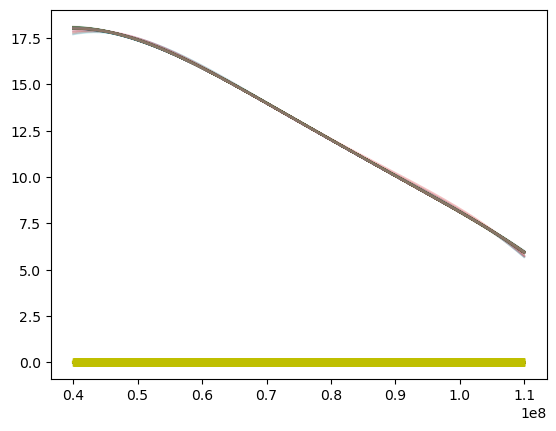

In [38]:
T_mean = np.mean(TA, axis=0)
lower_bound, upper_bound = np.percentile(TA,[16,84],axis=0)
plt.plot(req_freq, TA.T, alpha=0.1)
plt.plot(req_freq, T_mean, lw=2, color='y', marker='|', label="Mean")
#plt.fill_between(req_freq, lower_bound, upper_bound, color='b', zorder=-1, label="1 sigma")

In [56]:
res.shape

(375000, 2294)

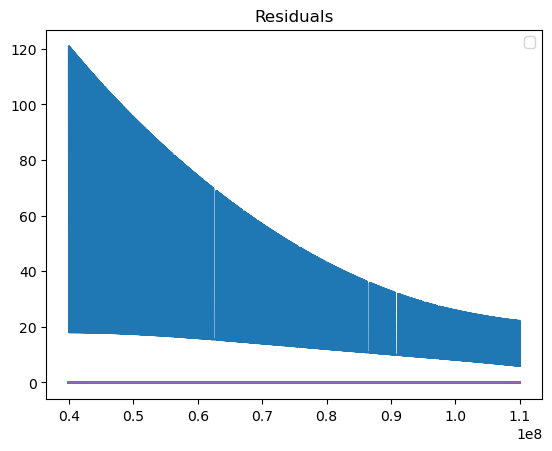

In [39]:
plt.figure()
plt.plot(req_freq, res[::1000].T,zorder=0)
#plt.plot(req_freq,TMeas,'.k', label='Actual', zorder=1)
plt.title("Residuals")
plt.legend()

In [59]:
lower_bound, median, upper_bound = np.percentile(res,[16,50,84],axis=0)
print(lower_bound, upper_bound)

[0. 0. 0. ... 0. 0. 0.] [0. 0. 0. ... 0. 0. 0.]


In [60]:
print(lower_bound, upper_bound)
print(np.sum(lower_boundr_bound),np.sum(upper_bound))

[0. 0. 0. ... 0. 0. 0.] [0. 0. 0. ... 0. 0. 0.]
0.0 0.0


In [ ]:
plt.imshow(res)